# Candlestick Pattern Tracker

Track and analyze candlestick pattern occurrences by year.


In [20]:
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from BSquant import process_data
from BSquant import cs_pattern_recognition

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


In [21]:
# Configuration
ticker = 'MSFT'  # Change as needed
start_date = '1992-01-01'
end_date = '2022-12-31'

print(f"Downloading data for {ticker}...")

# Download data
data_raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

# Handle MultiIndex columns
if isinstance(data_raw.columns, pd.MultiIndex):
    data_raw.columns = data_raw.columns.get_level_values(0)

# Reset index and rename columns
data = data_raw.reset_index()
data.rename(columns={
    'Date': 'date',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'vol'
}, inplace=True)

# Convert date to timezone-naive datetime
if pd.api.types.is_datetime64_any_dtype(data['date']):
    data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
else:
    data['date'] = pd.to_datetime(data['date'])

print(f"Downloaded {len(data)} records")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")


Downloaded 7809 records
Date range: 1992-01-02 00:00:00 to 2022-12-30 00:00:00


In [22]:
# Process data
df = process_data(df=data)
print(f"Processed data: {len(df)} records")


Processed data: 7808 records


In [23]:
# Detect candlestick patterns
cs_signals_df = cs_pattern_recognition(df=df)
print(f"Total pattern instances detected: {len(cs_signals_df)}")


Total pattern instances detected: 15481


In [24]:
# Count patterns by type
if len(cs_signals_df) > 0:
    pattern_counts = cs_signals_df.reset_index().groupby('candle').size().sort_values(ascending=False)
    pattern_counts_df = pd.DataFrame({
        'Pattern': pattern_counts.index,
        'Total Occurrences': pattern_counts.values
    })
    
    print("\n=== Pattern Counts ===")
    print(pattern_counts_df.to_string(index=False))
else:
    print("No patterns detected.")



=== Pattern Counts ===
            Pattern  Total Occurrences
        CDLLONGLINE               1646
     CDLSPINNINGTOP               1637
        CDLBELTHOLD               1235
 CDLCLOSINGMARUBOZU               1181
            CDLDOJI               1012
  CDLLONGLEGGEDDOJI               1012
        CDLHIGHWAVE                991
         CDLHIKKAKE                935
       CDLSHORTLINE                895
     CDLRICKSHAWMAN                747
       CDLENGULFING                662
          CDLHARAMI                635
        CDLMARUBOZU                388
        CDL3OUTSIDE                306
     CDLHARAMICROSS                196
      CDLHANGINGMAN                182
        CDLDOJISTAR                176
          CDLHAMMER                157
         CDL3INSIDE                148
     CDLMATCHINGLOW                137
   CDLDRAGONFLYDOJI                115
          CDLTAKURI                115
  CDLINVERTEDHAMMER                113
  CDLGRAVESTONEDOJI                106
 

In [25]:
# Count patterns by year
if len(cs_signals_df) > 0:
    cs_signals_reset = cs_signals_df.reset_index()
    cs_signals_reset['year'] = pd.to_datetime(cs_signals_reset['date']).dt.year
    
    # Count by pattern and year
    yearly_counts = cs_signals_reset.groupby(['candle', 'year']).size().reset_index(name='count')
    yearly_pivot = yearly_counts.pivot(index='candle', columns='year', values='count').fillna(0).astype(int)
    
    # Sort by total occurrences
    yearly_pivot['Total'] = yearly_pivot.sum(axis=1)
    yearly_pivot = yearly_pivot.sort_values('Total', ascending=False)
    yearly_pivot = yearly_pivot.drop('Total', axis=1)
    
    print("\n=== Pattern Occurrences by Year ===")
    print(yearly_pivot.to_string())
    
    # Also show summary by year (all patterns combined)
    print("\n=== Total Pattern Occurrences by Year ===")
    yearly_summary = cs_signals_reset.groupby('year').size().reset_index(name='Total Patterns')
    yearly_summary = yearly_summary.sort_values('year')
    print(yearly_summary.to_string(index=False))
else:
    print("No patterns detected.")



=== Pattern Occurrences by Year ===
year                 1992  1993  1994  1995  1996  1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022
candle                                                                                                                                                                                                       
CDLLONGLINE            51    54    52    60    60    55    53    52    58    57    63    66    56    50    39    51    63    56    41    42    54    57    41    53    56    44    53    47    51    51    60
CDLSPINNINGTOP         55    43    49    37    41    49    45    49    53    39    43    61    64    56    72    68    50    66    60    48    66    54    52    66    53    51    57    47    42    55    46
CDLBELTHOLD            37    29    35    41    45    34    45    49    47    47    44    30    33    40    42    41    50    41    42    39

In [26]:
# Summary statistics
if len(cs_signals_df) > 0:
    cs_signals_reset = cs_signals_df.reset_index()
    cs_signals_reset['year'] = pd.to_datetime(cs_signals_reset['date']).dt.year
    
    summary_stats = {
        'Total Patterns': len(cs_signals_df),
        'Unique Pattern Types': cs_signals_reset['candle'].nunique(),
        'Years Covered': f"{cs_signals_reset['year'].min()} - {cs_signals_reset['year'].max()}",
        'Average Patterns per Year': round(len(cs_signals_df) / cs_signals_reset['year'].nunique(), 2),
        'Most Common Pattern': cs_signals_reset['candle'].value_counts().index[0],
        'Most Common Pattern Count': cs_signals_reset['candle'].value_counts().iloc[0]
    }
    
    print("\n=== Summary Statistics ===")
    for key, value in summary_stats.items():
        print(f"{key}: {value}")



=== Summary Statistics ===
Total Patterns: 15481
Unique Pattern Types: 56
Years Covered: 1992 - 2022
Average Patterns per Year: 499.39
Most Common Pattern: CDLLONGLINE
Most Common Pattern Count: 1646


In [27]:
# Get latest year data and top 10 patterns
if len(cs_signals_df) > 0:
    cs_signals_reset = cs_signals_df.reset_index()
    cs_signals_reset['year'] = pd.to_datetime(cs_signals_reset['date']).dt.year
    
    # Get latest year
    latest_year = cs_signals_reset['year'].max()
    print(f"\n=== Analyzing patterns for year {latest_year} ===")
    
    # Filter to latest year
    latest_year_data = df[df['date'].dt.year == latest_year].copy()
    latest_year_data_sorted = latest_year_data.sort_values('date')  # Sort for charting
    latest_year_patterns = cs_signals_reset[cs_signals_reset['year'] == latest_year].copy()
    
    # Get top 10 patterns for latest year
    top_patterns = latest_year_patterns['candle'].value_counts().head(10).index.tolist()
    
    print(f"Total patterns in {latest_year}: {len(latest_year_patterns)}")
    print(f"Top 10 patterns: {top_patterns}")
    
    # Filter patterns to top 10
    latest_year_patterns_top10 = latest_year_patterns[latest_year_patterns['candle'].isin(top_patterns)].copy()
    
    print(f"\nTop 10 pattern counts in {latest_year}:")
    print(latest_year_patterns_top10['candle'].value_counts())
else:
    print("No patterns detected.")



=== Analyzing patterns for year 2022 ===
Total patterns in 2022: 463
Top 10 patterns: ['CDLLONGLINE', 'CDLCLOSINGMARUBOZU', 'CDLSPINNINGTOP', 'CDLBELTHOLD', 'CDLHIGHWAVE', 'CDLDOJI', 'CDLLONGLEGGEDDOJI', 'CDLSHORTLINE', 'CDLRICKSHAWMAN', 'CDLHARAMI']

Top 10 pattern counts in 2022:
candle
CDLLONGLINE           60
CDLCLOSINGMARUBOZU    49
CDLSPINNINGTOP        46
CDLBELTHOLD           43
CDLDOJI               28
CDLHIGHWAVE           28
CDLLONGLEGGEDDOJI     28
CDLSHORTLINE          22
CDLRICKSHAWMAN        21
CDLHARAMI             20
Name: count, dtype: int64


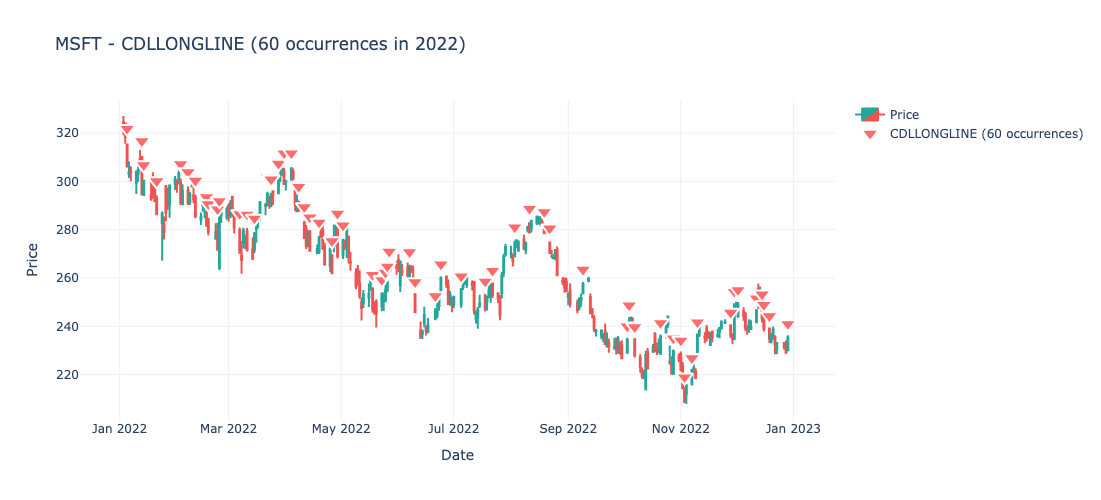

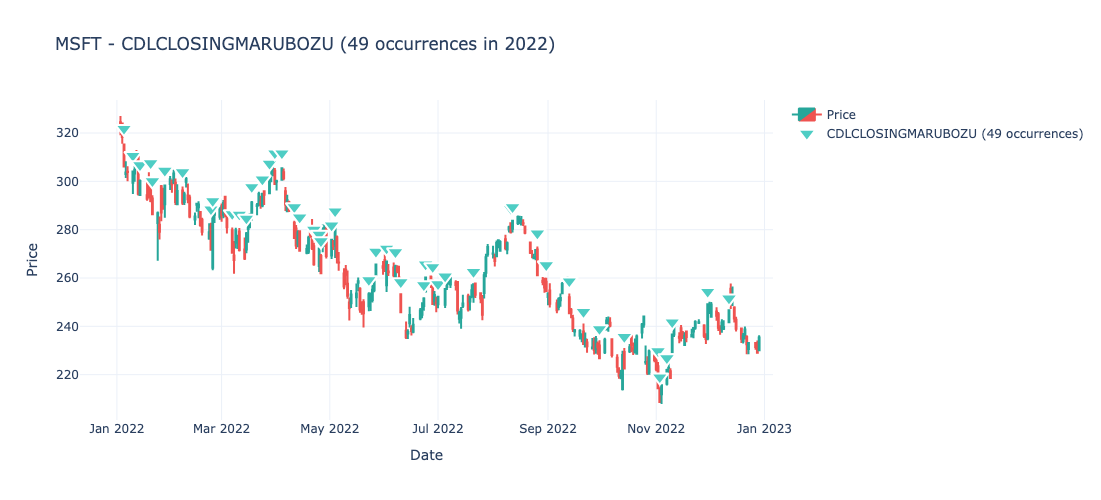

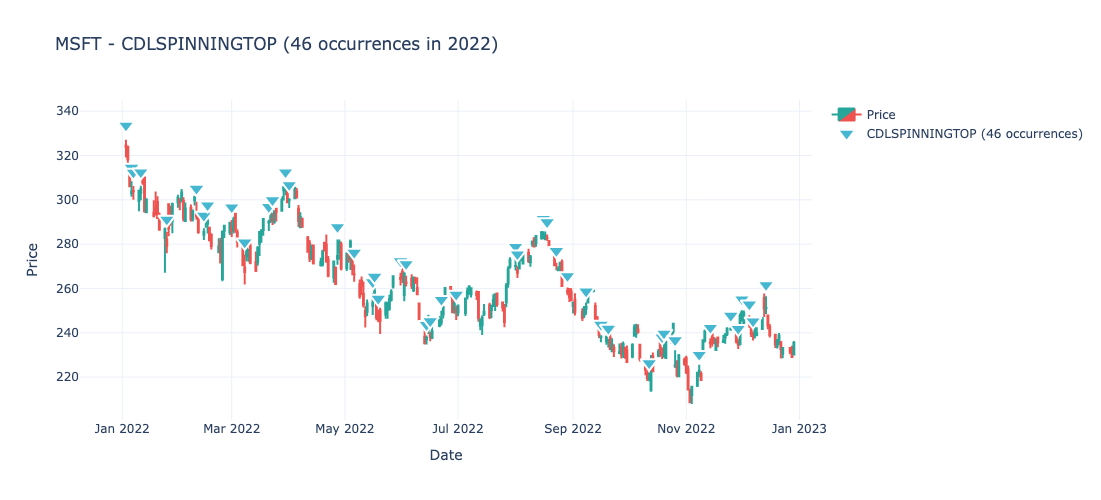

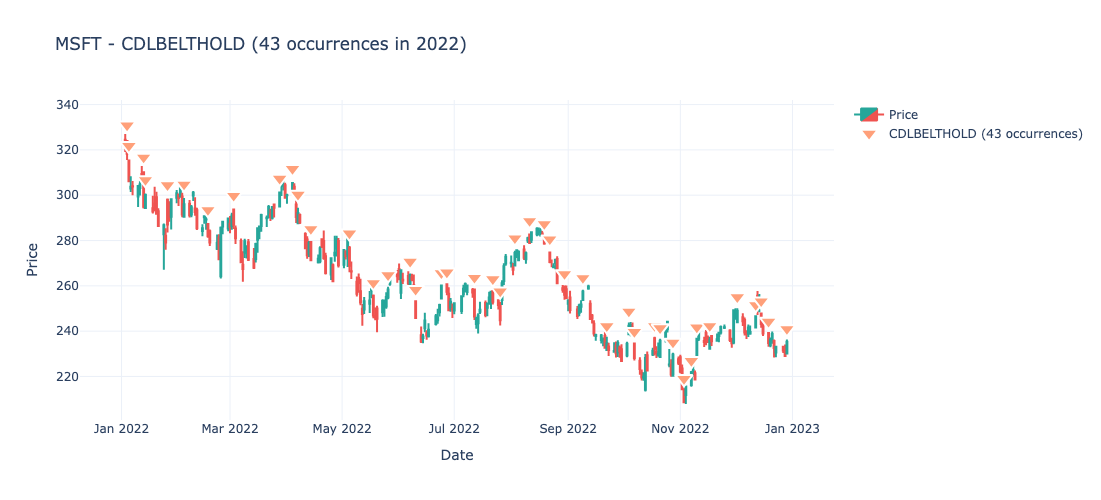

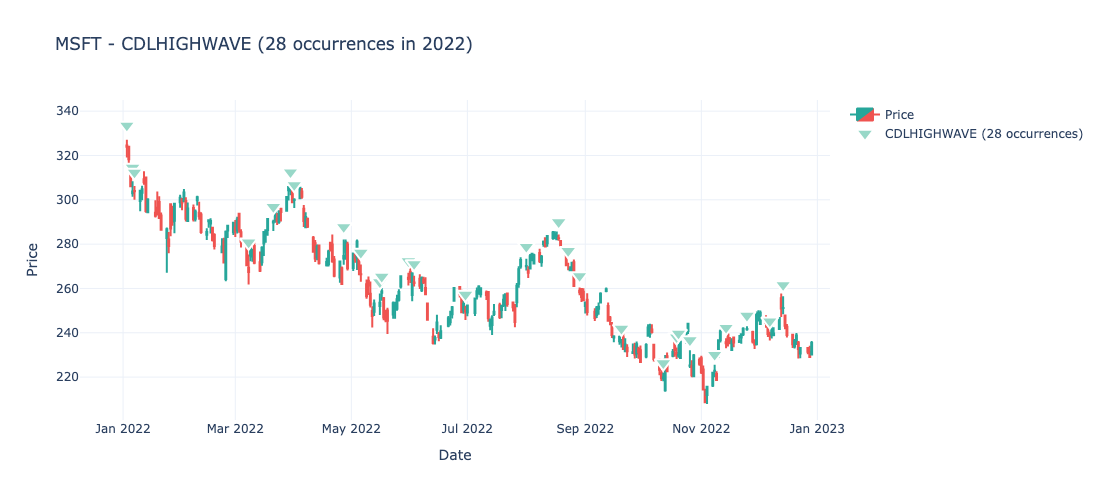

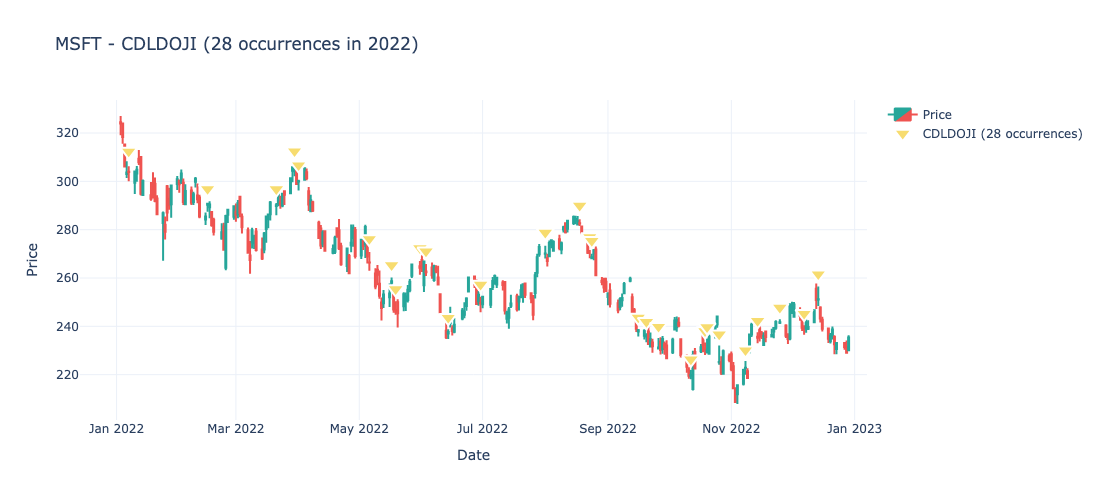

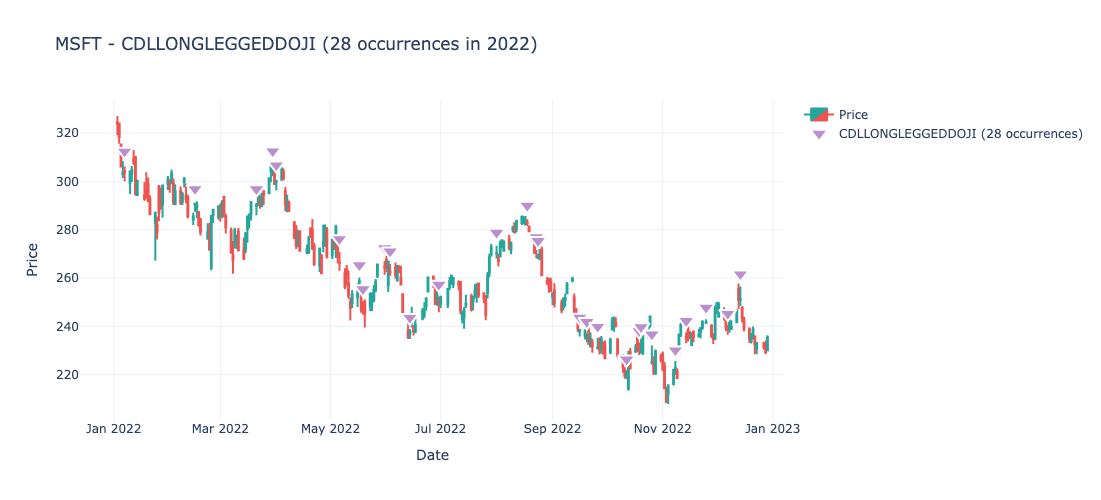

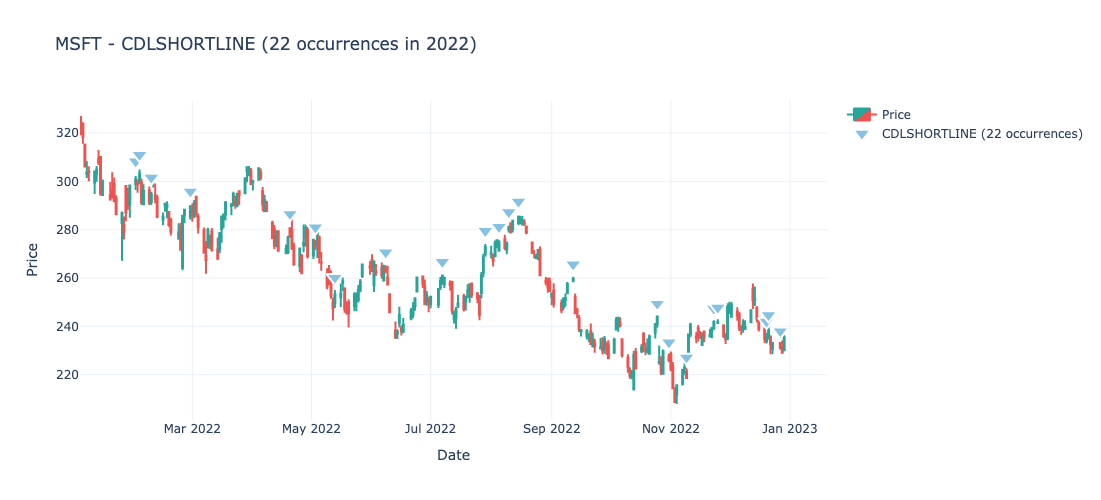

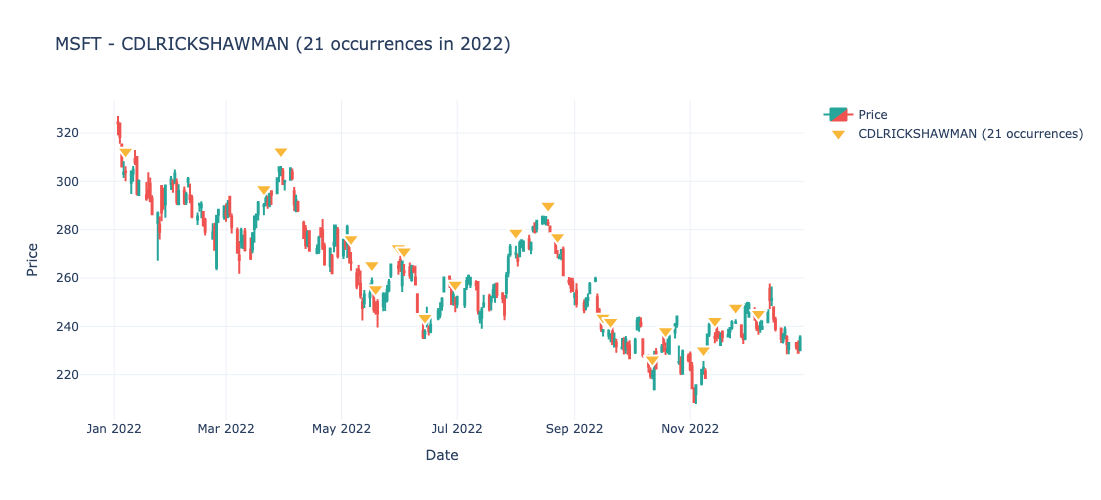

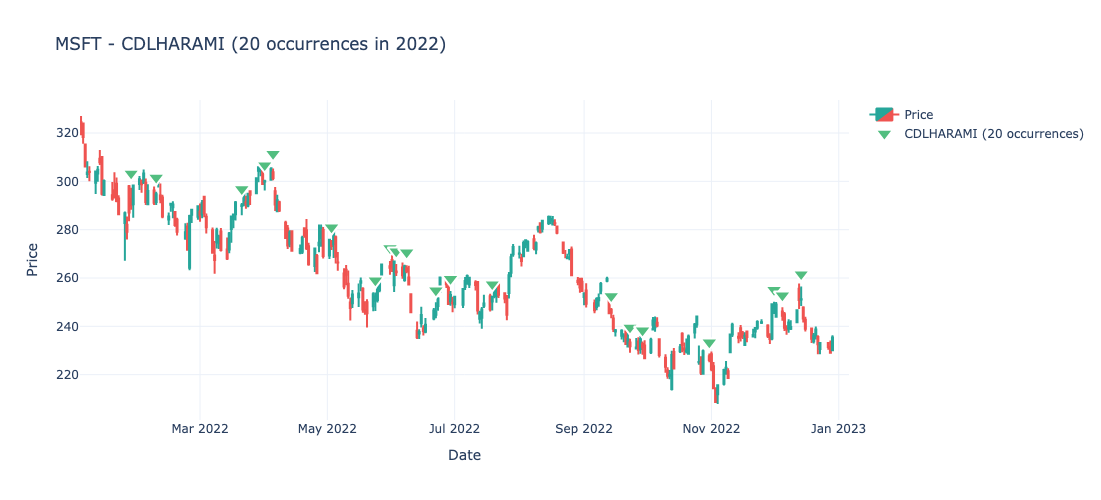

In [ ]:
# Pattern charts removed - focusing on backtesting analysis


# Backtesting: Indecision Reversal Strategy

This section implements a backtesting framework for the "Indecision Reversal" trading strategy using CDLDOJI and CDLSPINNINGTOP patterns.


In [ ]:
import talib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Filter data to 2002-2022 for backtesting (20 years)
data_backtest = data[(data['date'].dt.year >= 2002) & (data['date'].dt.year <= 2022)].copy().reset_index(drop=True)
print(f"Data for 2002-2022: {len(data_backtest)} records")
print(f"Date range: {data_backtest['date'].min()} to {data_backtest['date'].max()}")
print(f"Years covered: {data_backtest['date'].dt.year.min()} to {data_backtest['date'].dt.year.max()}")
data_backtest.head()


In [ ]:
def backtest_strategy(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.02, hold_days=5):
    """
    Backtest the Indecision Reversal trading strategy.
    
    Strategy Rules:
    - Long Entry: CDLDOJI or CDLSPINNINGTOP after 3-5 day downtrend (price < 20-day SMA, 
                  last 3 closes decreasing), confirmed by next candle closing higher
    - Short Entry: Similar but after uptrend, confirmed by next candle closing lower
    - Exit: Hold for 5 days or until opposite signal, whichever comes first
    - Stop-loss: 2% from entry price
    - Position sizing: Risk 1% of capital per trade
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 2% = 0.02)
    hold_days : int
        Maximum holding period in days (default: 5)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data for 20-day SMA
    if len(df) < 20:
        return {
            'error': f'Insufficient data: need at least 20 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Calculate 20-day Simple Moving Average
    df['sma_20'] = df['close'].rolling(window=20, min_periods=20).mean()
    
    # Detect candlestick patterns using TA-Lib
    # Note: TA-Lib expects numpy arrays
    df['CDLDOJI'] = talib.CDLDOJI(df['open'].values, df['high'].values, 
                                   df['low'].values, df['close'].values)
    df['CDLSPINNINGTOP'] = talib.CDLSPINNINGTOP(df['open'].values, df['high'].values, 
                                                 df['low'].values, df['close'].values)
    
    # Pattern signal: 1 if pattern detected (non-zero), 0 otherwise
    df['pattern_signal'] = ((df['CDLDOJI'] != 0) | (df['CDLSPINNINGTOP'] != 0)).astype(int)
    
    # Determine trend direction
    # Downtrend: price < SMA_20 AND last 3 closes are decreasing
    df['below_sma'] = (df['close'] < df['sma_20']).astype(int)
    df['uptrend'] = (df['close'] > df['sma_20']).astype(int)
    
    # Check if last 3 closes are decreasing (for downtrend) or increasing (for uptrend)
    df['close_shift1'] = df['close'].shift(1)
    df['close_shift2'] = df['close'].shift(2)
    df['close_shift3'] = df['close'].shift(3)
    
    # Downtrend: last 3 closes decreasing
    df['decreasing_closes'] = (
        (df['close'] < df['close_shift1']) & 
        (df['close_shift1'] < df['close_shift2']) &
        (df['close_shift2'] < df['close_shift3'])
    ).astype(int)
    
    # Uptrend: last 3 closes increasing
    df['increasing_closes'] = (
        (df['close'] > df['close_shift1']) & 
        (df['close_shift1'] > df['close_shift2']) &
        (df['close_shift2'] > df['close_shift3'])
    ).astype(int)
    
    # Long entry conditions: pattern + downtrend + confirmation
    df['long_setup'] = (
        (df['pattern_signal'] == 1) & 
        (df['below_sma'] == 1) & 
        (df['decreasing_closes'] == 1)
    ).astype(int)
    
    # Long confirmation: next candle closes higher than pattern candle
    df['next_close'] = df['close'].shift(-1)
    df['long_confirmation'] = (df['next_close'] > df['close']).astype(int)
    df['long_signal'] = (df['long_setup'] & df['long_confirmation']).astype(int)
    
    # Short entry conditions: pattern + uptrend + confirmation
    df['short_setup'] = (
        (df['pattern_signal'] == 1) & 
        (df['uptrend'] == 1) & 
        (df['increasing_closes'] == 1)
    ).astype(int)
    
    # Short confirmation: next candle closes lower than pattern candle
    df['short_confirmation'] = (df['next_close'] < df['close']).astype(int)
    df['short_signal'] = (df['short_setup'] & df['short_confirmation']).astype(int)
    
    # Initialize trading variables
    capital = initial_capital
    position = None  # 'long', 'short', or None
    entry_price = None
    entry_date = None
    entry_index = None
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades
    for i in range(len(df)):
        current_price = df.loc[i, 'close']
        current_date = df.loc[i, 'date']
        
        # Check for stop-loss if in position
        if position is not None:
            if position == 'long':
                # Long stop-loss: exit if price drops 2% below entry
                if current_price <= entry_price * (1 - stop_loss_pct):
                    # Exit trade
                    pnl = (current_price - entry_price) / entry_price
                    trade_value = capital * (1 + pnl)
                    capital = trade_value
                    
                    trades.append({
                        'entry_date': entry_date,
                        'exit_date': current_date,
                        'entry_price': entry_price,
                        'exit_price': current_price,
                        'position': position,
                        'pnl': pnl,
                        'pnl_pct': pnl * 100,
                        'exit_reason': 'stop_loss',
                        'hold_days': (current_date - entry_date).days
                    })
                    
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
                    
            elif position == 'short':
                # Short stop-loss: exit if price rises 2% above entry
                if current_price >= entry_price * (1 + stop_loss_pct):
                    # Exit trade
                    pnl = (entry_price - current_price) / entry_price
                    trade_value = capital * (1 + pnl)
                    capital = trade_value
                    
                    trades.append({
                        'entry_date': entry_date,
                        'exit_date': current_date,
                        'entry_price': entry_price,
                        'exit_price': current_price,
                        'position': position,
                        'pnl': pnl,
                        'pnl_pct': pnl * 100,
                        'exit_reason': 'stop_loss',
                        'hold_days': (current_date - entry_date).days
                    })
                    
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
        
        # Check for exit conditions if in position
        if position is not None:
            days_held = (current_date - entry_date).days
            
            # Exit after hold_days
            if days_held >= hold_days:
                # Exit trade
                if position == 'long':
                    pnl = (current_price - entry_price) / entry_price
                else:  # short
                    pnl = (entry_price - current_price) / entry_price
                
                trade_value = capital * (1 + pnl)
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'exit_reason': 'time_limit',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
            
            # Exit on opposite signal
            elif (position == 'long' and df.loc[i, 'short_signal'] == 1) or \
                 (position == 'short' and df.loc[i, 'long_signal'] == 1):
                # Exit trade
                if position == 'long':
                    pnl = (current_price - entry_price) / entry_price
                else:  # short
                    pnl = (entry_price - current_price) / entry_price
                
                trade_value = capital * (1 + pnl)
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'exit_reason': 'opposite_signal',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
        
        # Check for new entry signals (only if not in position)
        if position is None:
            # Long entry signal
            if df.loc[i, 'long_signal'] == 1:
                position = 'long'
                entry_price = df.loc[i, 'next_close']  # Enter on next day's close (confirmation)
                entry_date = df.loc[i+1, 'date'] if i+1 < len(df) else current_date
                entry_index = i+1 if i+1 < len(df) else i
                # Note: In real trading, we'd enter at next day's open, but using close for simplicity
            
            # Short entry signal
            elif df.loc[i, 'short_signal'] == 1:
                position = 'short'
                entry_price = df.loc[i, 'next_close']  # Enter on next day's close (confirmation)
                entry_date = df.loc[i+1, 'date'] if i+1 < len(df) else current_date
                entry_index = i+1 if i+1 < len(df) else i
        
        # Update equity curve
        equity_curve.append(capital)
    
    # Close any open position at the end
    if position is not None:
        final_price = df.loc[len(df)-1, 'close']
        if position == 'long':
            pnl = (final_price - entry_price) / entry_price
        else:  # short
            pnl = (entry_price - final_price) / entry_price
        
        trade_value = capital * (1 + pnl)
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        # Total return
        total_return = (capital - initial_capital) / initial_capital
        
        # Win rate
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        
        # Average win/loss
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        # Max drawdown
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (assuming daily returns, risk-free rate = 0%)
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        # Total number of trades
        total_trades = len(trades_df)
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist()
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist()
        }
    
    return results


In [ ]:
# Run backtest
print("Running backtest for Indecision Reversal Strategy (2002-2022)...")
print("="*60)

results = backtest_strategy(
    data=data_backtest,
    initial_capital=10000,
    risk_per_trade=0.01,
    stop_loss_pct=0.02,
    hold_days=5
)

# Display results
print(f"\n{'='*60}")
print("BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Initial Capital: ${results['initial_capital']:,.2f}")
print(f"Final Capital: ${results['final_capital']:,.2f}")
print(f"Total Return: {results['total_return_pct']:.2f}%")
print(f"\nTotal Trades: {results['total_trades']}")
print(f"Win Rate: {results['win_rate_pct']:.2f}%")
print(f"Average Win: {results['avg_win_pct']:.2f}%")
print(f"Average Loss: {results['avg_loss_pct']:.2f}%")
print(f"Max Drawdown: {results['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio: {results['sharpe_ratio']:.2f}")
print(f"{'='*60}")

# Display trades if any
if len(results['trades']) > 0:
    print(f"\nTrade Details (showing first 10):")
    print(results['trades'].head(10).to_string(index=False))
else:
    print("\nNo trades executed during the backtest period.")


In [ ]:
# Plot cumulative returns (equity curve)
if len(results['equity_curve']) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Equity curve
    dates_extended = [results['dates'][0]] + results['dates']
    ax1.plot(dates_extended, results['equity_curve'], linewidth=2, color='#2E86AB', label='Portfolio Value')
    ax1.axhline(y=results['initial_capital'], color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax1.set_title(f'Indecision Reversal Strategy - Equity Curve ({ticker} 2002-2022)', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Drawdown chart
    equity_array = np.array(results['equity_curve'])
    running_max = np.maximum.accumulate(equity_array)
    drawdown = (equity_array - running_max) / running_max * 100
    ax2.fill_between(dates_extended, drawdown, 0, color='#E63946', alpha=0.3, label='Drawdown')
    ax2.plot(dates_extended, drawdown, color='#E63946', linewidth=1)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_title('Drawdown Over Time', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"\n{'='*60}")
    print("ADDITIONAL STATISTICS")
    print(f"{'='*60}")
    print(f"Best Day: ${max(np.diff(results['equity_curve'])):,.2f}")
    print(f"Worst Day: ${min(np.diff(results['equity_curve'])):,.2f}")
    print(f"Final Drawdown: {drawdown[-1]:.2f}%")
    print(f"Max Drawdown Date: {dates_extended[np.argmin(drawdown)]}")
else:
    print("No equity curve data to plot.")


In [ ]:
# Trade analysis by exit reason
if len(results['trades']) > 0:
    trades_df = results['trades']
    
    print(f"\n{'='*60}")
    print("TRADE ANALYSIS BY EXIT REASON")
    print(f"{'='*60}")
    
    exit_reason_stats = trades_df.groupby('exit_reason').agg({
        'pnl': ['count', 'mean', 'sum'],
        'hold_days': 'mean'
    }).round(4)
    
    exit_reason_stats.columns = ['Count', 'Avg PnL', 'Total PnL', 'Avg Hold Days']
    exit_reason_stats['Avg PnL %'] = exit_reason_stats['Avg PnL'] * 100
    exit_reason_stats['Total PnL %'] = exit_reason_stats['Total PnL'] * 100
    
    print(exit_reason_stats.to_string())
    
    # Position type analysis
    print(f"\n{'='*60}")
    print("TRADE ANALYSIS BY POSITION TYPE")
    print(f"{'='*60}")
    
    position_stats = trades_df.groupby('position').agg({
        'pnl': ['count', 'mean', 'sum'],
        'hold_days': 'mean'
    }).round(4)
    
    position_stats.columns = ['Count', 'Avg PnL', 'Total PnL', 'Avg Hold Days']
    position_stats['Avg PnL %'] = position_stats['Avg PnL'] * 100
    position_stats['Total PnL %'] = position_stats['Total PnL'] * 100
    
    print(position_stats.to_string())
else:
    print("No trades to analyze.")


In [ ]:
# Compare with buy-and-hold strategy
if len(data_backtest) > 0:
    buy_hold_return = (data_backtest['close'].iloc[-1] - data_backtest['close'].iloc[0]) / data_backtest['close'].iloc[0]
    buy_hold_final = results['initial_capital'] * (1 + buy_hold_return)
    
    print(f"\n{'='*60}")
    print("STRATEGY COMPARISON")
    print(f"{'='*60}")
    print(f"{'Metric':<25} {'Strategy':<20} {'Buy & Hold':<20}")
    print(f"{'-'*65}")
    print(f"{'Initial Capital':<25} ${results['initial_capital']:,.2f}{'':<15} ${results['initial_capital']:,.2f}")
    print(f"{'Final Capital':<25} ${results['final_capital']:,.2f}{'':<15} ${buy_hold_final:,.2f}")
    print(f"{'Total Return':<25} {results['total_return_pct']:>6.2f}%{'':<13} {buy_hold_return*100:>6.2f}%")
    print(f"{'='*60}")
    
    # Plot comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Strategy equity curve
    dates_extended = [results['dates'][0]] + results['dates']
    ax.plot(dates_extended, results['equity_curve'], linewidth=2, color='#2E86AB', label='Indecision Reversal Strategy', alpha=0.8)
    
    # Buy-and-hold equity curve
    buy_hold_curve = [results['initial_capital']]
    for i in range(1, len(data_backtest)):
        return_so_far = (data_backtest['close'].iloc[i] - data_backtest['close'].iloc[0]) / data_backtest['close'].iloc[0]
        buy_hold_curve.append(results['initial_capital'] * (1 + return_so_far))
    
    ax.plot(data_backtest['date'], buy_hold_curve, linewidth=2, color='#F77F00', label='Buy & Hold', alpha=0.8)
    ax.axhline(y=results['initial_capital'], color='gray', linestyle='--', alpha=0.5)
    
    ax.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'Strategy Comparison: Indecision Reversal vs Buy & Hold ({ticker} 2002-2022)', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
